# Individual energy profiles — real vs every method

One panel per curve: the real profile of a single (process, sensor, activity)
execution and, on top of it, what every method predicted for that same curve.
Three curves per process, laid out in a grid of three columns.

Which curves are drawn is not a hand-pick: per process they are the ones the
BEST method — the approach with the lowest Overall realism error in
`03_results.ipynb` — reproduces most faithfully, i.e. its highest-realism
curves. Degenerate curves are excluded first (see `MIN_*` in the config): a flat
zero real profile is trivially matched by everything and shows nothing.

The realism error is the one the individual-profile table reports,
`err_f = |f(pred) - f(real)| / mean|f(real)|` over Sum / Max / Mean / Std /
Roughness, normalised per (process, sensor); Overall is their mean, 0 = perfect.


## 0 · Config

In [1]:

# ── What to read ─────────────────────────────────────────────────────────────
EXPERIMENT = 1        # experiment number; the latest run of it is used
RUN        = None     # None = latest run of EXPERIMENT; or a full directory name
                      # / any substring of one, e.g. 'experiment_1_20260801'
SPLIT      = 'TEST'   # 'TEST' | 'TRAIN' — the split the curves are drawn from

# ── The figure ───────────────────────────────────────────────────────────────
N_PER_PROCESS = 3     # curves drawn per process
N_COLS        = 3     # columns of the grid
SAVE_PDF      = 'visuals/individual_profiles_grid.pdf'   # None = do not save

# Identity labels become shuffled numbers, with the SAME seed as 03_results.ipynb,
# so 'Process 4 / Sensor 12 / Activity 7' means the same thing in both.
ANONYMISE = True
ANON_SEED = 20260730

# ── Which method is 'best', and which methods are drawn ──────────────────────
# None = the approach with the lowest Overall realism, ranked exactly as the
# individual-profile table ranks it (median over cells of the per-cell median).
# Or pin one by its DISPLAY name, e.g. 'ML Step DTW (proposed)'.
BEST_METHOD       = None
SHOW_METHODS      = None   # None = every approach in the run; or a list of display names
EXCLUDE_APPROACHES = ['Exemplar (real curve)', 'Exemplar (no DTW)',
                      'Exemplar + DTW (warped)']        # raw names, dropped everywhere

# ── Which curves qualify ─────────────────────────────────────────────────────
# Without these the winners are all degenerate: a real curve that is flat zero
# scores a realism error of exactly 0 for every method, so the top of the ranking
# fills up with empty profiles that show nothing.
MIN_CURVE_POINTS   = 15     # samples in the curve — long enough to have a shape
MIN_REL_STD        = 0.02   # std|real| / max|real| — reject flat lines
MIN_REL_MAGNITUDE  = 0.25   # max|real| relative to the sensor's mean max|real| —
                            # reject curves that are near-zero for their sensor
MIN_DUTY           = 0.10   # mean|real| / max|real| — reject a curve that is zero
                            # except for one spike (there mean/max ~ 1/N): it passes
                            # the two filters above on the spike alone and draws an
                            # empty panel with a needle in it
MAX_REALISM        = 0.50   # best-method realism ceiling — a curve missed this
                            # badly draws a failure panel, not a comparison; it
                            # matters when EXCLUDE_SENSORS thins a process's pool
                            # and the diversity pass would otherwise reach for one
DIVERSIFY          = 'sensor+activity'   # 'sensor' | 'sensor+activity' | None — at
                                # most one curve per key, so a process does not show
                                # three executions of the same thing. 'sensor' spreads
                                # wider but can cost a lot of realism on the third
                                # panel, when a process has only two sensors the best
                                # method reproduces well.

# Sensors never drawn for a process, keyed by the DISPLAYED labels (so with
# ANONYMISE the anonymised ones). The realism filters cannot see what a panel
# looks like: on these processes the winners are intermittent on/off signals
# whose spikes rarely coincide, and every panel reads as noise. Dropping the
# sensors hands the selection to the next ones — batch-shaped curves the eye
# can actually follow — at the price of a higher realism number in the corner.
EXCLUDE_SENSORS = {
    'Process 1': ['Sensor 69', 'Sensor 71'],
    'Process 6': ['Sensor 16', 'Sensor 53'],
}

# Panels cut from the AUTOMATIC selection and not refilled — the figure is meant
# to get smaller, not to swap curves in. (Process, Sensor, Activity), displayed
# labels; every selected curve matching a triple is dropped.
REMOVE_CURVES = [
    ('Process 3', 'Sensor 25', 'Activity 16'),
    ('Process 5', 'Sensor 46', 'Activity 29'),
    ('Process 6', 'Sensor 68', 'Activity 23'),
]

# ── Metrics behind the ranking (identical to 03_results.ipynb, section I) ────
REALISM_SPECS = {
    'Sum':       ('sum_pred',   'sum_real'),    # total energy over the curve
    'Max':       ('max_pred',   'max_real'),    # peak — sizing and tariffs
    'Mean':      ('mean_pred',  'mean_real'),   # average load level = the bias
    'Std':       ('std_pred',   'std_real'),    # spread — the flatness measure
    'Roughness': ('rough_pred', 'rough_real'),  # jaggedness
}
RANK_MIN_CURVE_POINTS = 5      # curve-length floor used for the RANKING only
LEVEL_CELL_COVERAGE   = True   # rank on the cells every approach is scored on

# Paper naming — kept IDENTICAL to I_METHOD_RENAME in 03_results.ipynb, so a
# method is called the same thing in this figure and in the results tables.
METHOD_RENAME = {
    'Step DTW smooth + ML + Ext.':    'ML Step DTW (proposed)',
    'Step DTW + ML + Ext.':           'Step DTW (step gains)',
    'ML + Ext. Factors':              'ML DTW (no steps)',
    'DTW + ML + Ext. Factors':        'ML DTW (no steps)',
    'ML DTW':                         'Step DTW w/o segments and ext.',
    'DTW + ML':                       'Step DTW w/o segments and ext.',
    'ML only (no DTW)':               'ML (no DTW)',
    'Median per Activity & Sensor':   'Median per Activity & Sensor',
    'Median per activity and sensor': 'Median per Activity & Sensor',
    'Baseline':                       'Sensor median',
    'DTW + Seq2Seq + Ext. Factors':   'Seq2Seq DTW (aligned)',
    'Seq2Seq IOM (DTW-selected)':     'Seq2Seq (DTW-scored)',
    'DTW + Seq2Seq':                  'Seq2Seq (aligned, w/o ext.)',
    'Seq2Seq only (no DTW)':          'Seq2Seq (unaligned)',
}

## 1 · Load the run

In [2]:

# ── Resolve the run and read the per-curve statistics (no curves yet) ─────────
import re
import numpy as np, pandas as pd
import pyarrow.dataset as ds, pyarrow.compute as pc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')

RESULTS_ROOT = Path('..') / 'results'

_runs = sorted((d for d in RESULTS_ROOT.iterdir()
                if d.is_dir() and (d / 'curve_eval_results.parquet').exists()),
               key=lambda d: d.name)
assert _runs, 'no run with curve_eval_results.parquet'

# 'latest' is the latest TIMESTAMP, not the last name alphabetically: a run that
# has been renamed (experiment_1_old_20260730_...) still starts with the same
# experiment prefix and sorts after the newer one, which would silently read a
# superseded run. The name is matched strictly as experiment_<n>_<date>_<time>.
_RUN_RE = re.compile(r'^experiment_(?P<exp>.+?)_(?P<stamp>\d{8}_\d{6})$')

def _stamp(d):
    m = _RUN_RE.match(d.name)
    return m.group('stamp') if m else ''

if RUN:
    _match = [d for d in _runs if d.name == RUN] or [d for d in _runs if RUN in d.name]
    assert _match, f'RUN={RUN!r} matches none of: ' + ', '.join(d.name for d in _runs)
    run_dir = max(_match, key=_stamp)
else:
    _exp = [d for d in _runs
            if (_m := _RUN_RE.match(d.name)) and _m.group('exp') == str(EXPERIMENT)]
    assert _exp, (f'no run named experiment_{EXPERIMENT}_<date>_<time>; '
                  'set RUN explicitly. Available: ' + ', '.join(d.name for d in _runs))
    run_dir = max(_exp, key=_stamp)
print('Run:', run_dir.name)
_other = [d.name for d in _runs if d is not run_dir]
print('     (other runs present: ' + ', '.join(_other) + ')' if _other else '')

# Sample spacing, so the x axis can be minutes instead of sample numbers.
_info = json.loads((run_dir / 'info.json').read_text()) if (run_dir / 'info.json').exists() else {}
_res  = str(_info.get('temporal_resolution', '1min'))
_m    = re.fullmatch(r'(\d+)\s*min', _res)
DT_MIN  = float(_m.group(1)) if _m else None      # None = unknown spacing
X_LABEL = ('minutes since activity start' if DT_MIN
           else f'samples since activity start ({_res})')
print(f'Temporal resolution: {_res}  ->  x axis in ' + ('minutes' if DT_MIN else 'samples'))

# Only the statistics columns — the curves themselves are read later, for the
# handful of instances that end up in the figure (the file holds ~400k of them).
_STAT_COLS = ['Approach', 'Process', 'Sensor', 'Split', 'Activity', 'Instance', 'N',
              'mean_real', 'std_real', 'max_real', 'rough_real',
              'mean_pred', 'std_pred', 'max_pred', 'rough_pred']
stats = pd.read_parquet(run_dir / 'curve_eval_results.parquet', columns=_STAT_COLS)
stats = stats[stats['Split'] == SPLIT]
if EXCLUDE_APPROACHES:
    stats = stats[~stats['Approach'].isin(EXCLUDE_APPROACHES)]
CURVE_KEY = ['Process', 'Sensor', 'Activity', 'Instance']
print(f'{len(stats):,} scored curves | {stats["Approach"].nunique()} approaches | '
      f'{stats.groupby(CURVE_KEY).ngroups:,} distinct curves | '
      f'{stats["Process"].nunique()} processes')

Run: experiment_1_20260802_085901
     (other runs present: 20260427_195021, experiment_1000_20260729_201444, experiment_2_20260801_164745, experiment_3_20260730_101913, experiment_976_20260726_103126, experiment_988_20260728_163037, experiment_999_20260729_175612)
Temporal resolution: 1min  ->  x axis in minutes
135,473 scored curves | 7 approaches | 19,403 distinct curves | 6 processes


In [3]:

# ── Anonymisation maps, built exactly as 03_results.ipynb builds them ────────
# Same population (this split, exclusions applied), same seeds, same order — so a
# number here is the number the individual-profile table uses.
def _anon_map(values, prefix, seed):
    labels = sorted(pd.Series(values).dropna().astype(str).unique())
    order  = np.random.default_rng(seed).permutation(len(labels)) + 1
    return {lab: f'{prefix} {n}' for lab, n in zip(labels, order)}

ANON = {}
if ANONYMISE:
    _pair = stats['Process'].astype(str) + ' | ' + stats['Sensor'].astype(str)
    ANON['Process']  = _anon_map(stats['Process'],  'Process',  ANON_SEED + 0)
    ANON['Activity'] = _anon_map(stats['Activity'], 'Activity', ANON_SEED + 1)
    ANON['Sensor']   = _anon_map(_pair,             'Sensor',   ANON_SEED + 2)
    print('Anonymised: ' + ', '.join(f'{k} ({len(v)})' for k, v in ANON.items()))

def label_process(p):
    return ANON['Process'][str(p)] if ANONYMISE else str(p)

def label_activity(a):
    return ANON['Activity'][str(a)] if ANONYMISE else str(a)

def label_sensor(p, s):
    return ANON['Sensor'][f'{p} | {s}'] if ANONYMISE else str(s)

# The unit survives anonymisation — it is a property of the signal, not an identity.
_UNITS = ['kg/h', 'g/kg', 'l/h', 'kWh', 'kW', 'm3/h', 'bar', 'kg', '%']
def sensor_unit(sensor):
    s = str(sensor)
    body = s[:-len('_energy_to_model')] if s.endswith('_energy_to_model') else s
    for u in _UNITS:
        if re.search(rf'(^|[_\W]){re.escape(u)}($|[_\W])', body, flags=re.I):
            return u
    if re.search(r'temp', body, flags=re.I):
        return '\u00b0C'
    return 'value'

Anonymised: Process (6), Activity (29), Sensor (79)


## 2 · Realism per curve, and the best method

In [4]:

# ── The realism error of every (curve, approach), then the approach ranking ──
# err_f = |f(pred) - f(real)| / mean|f(real)| of that (process, sensor), so the
# five features are comparable and 0 is a perfect reproduction. The SCALE is the
# sensor's typical magnitude over the whole run, not this curve's own — dividing
# by the curve itself would make a tiny curve unmissable and a large one easy.
for _side in ('real', 'pred'):
    stats[f'sum_{_side}'] = stats[f'mean_{_side}'] * stats['N']

_uniq = stats.drop_duplicates(['Process', 'Sensor', 'Instance', 'Activity'])
for _name, (_num, _den) in REALISM_SPECS.items():
    _by = (_uniq.groupby(['Process', 'Sensor'])[_den]
                .apply(lambda s: pd.to_numeric(s, errors='coerce').abs().mean()))
    _scale = (pd.MultiIndex.from_arrays([stats['Process'], stats['Sensor']])
                .map(_by).to_numpy(dtype=float))
    stats[_name] = np.where(np.isfinite(_scale) & (_scale > 1e-6),
                            (stats[_num] - stats[_den]).abs() / _scale, np.nan)

METRICS = [m for m in REALISM_SPECS if stats[m].notna().any()]
stats['Overall'] = stats[METRICS].mean(axis=1)
print('Realism metrics:', METRICS)

# The ranking population: the same levelling the table uses, so the method called
# best here is the method the table calls best.
CELL_KEY = ['Process', 'Activity', 'Sensor']
_rank = stats[stats['N'] >= RANK_MIN_CURVE_POINTS]
if LEVEL_CELL_COVERAGE:
    _cells = {a: set(map(tuple, g[CELL_KEY].drop_duplicates().to_numpy()))
              for a, g in _rank.groupby('Approach')}
    _shared = set.intersection(*_cells.values()) if _cells else set()
    _rank = _rank[_rank[CELL_KEY].apply(tuple, axis=1).isin(_shared)]
    print(f'Ranked on the {len(_shared)} (process, activity, sensor) cells every '
          f'approach is scored on')

_combo = _rank.groupby(CELL_KEY + ['Approach'])[METRICS].median().reset_index()
_combo['Overall'] = _combo[METRICS].mean(axis=1)
ranking = (_combo.groupby('Approach')[METRICS + ['Overall']].median()
                 .sort_values('Overall')
                 .rename(index=METHOD_RENAME).round(3))
stats['Method'] = stats['Approach'].replace(METHOD_RENAME)

if BEST_METHOD is None:
    BEST_METHOD = ranking.index[0]
assert BEST_METHOD in set(stats['Method']), \
    f'{BEST_METHOD!r} is not in this run: {sorted(set(stats["Method"]))}'
print(f'\nBest method: {BEST_METHOD}   (lowest Overall realism error)\n')
display(ranking)

Realism metrics: ['Sum', 'Max', 'Mean', 'Std', 'Roughness']
Ranked on the 390 (process, activity, sensor) cells every approach is scored on

Best method: ML Step DTW (proposed)   (lowest Overall realism error)



,Sum,Max,Mean,Std,Roughness,Overall
Approach,,,,,,
ML Step DTW (proposed),0.017,0.065,0.046,0.373,0.467,0.229
ML (no DTW),0.018,0.072,0.050,0.424,0.542,0.278
Median per Activity & Sensor,0.015,0.062,0.043,0.416,0.534,0.280
ML DTW (no steps),0.017,0.064,0.051,0.428,0.530,0.284
Sensor median,0.015,0.068,0.042,0.473,0.583,0.291
Seq2Seq (DTW-scored),0.020,0.083,0.061,0.565,0.655,0.334
Seq2Seq DTW (aligned),0.018,0.080,0.057,0.592,0.670,0.334


## 3 · The curves to draw

In [5]:

# ── Per process: the curves BEST_METHOD reproduces most faithfully ───────────
# The candidate pool is filtered first. A real profile that is flat, or ~zero for
# its sensor, is matched perfectly by every method — those curves top the ranking
# without showing anything, so they are not eligible.
_best = stats[stats['Method'] == BEST_METHOD].copy()
_sensor_scale = (_uniq.groupby(['Process', 'Sensor'])['max_real']
                      .apply(lambda s: s.abs().mean()))
_best['rel_magnitude'] = (_best['max_real'].abs().to_numpy() /
                          pd.MultiIndex.from_arrays([_best['Process'], _best['Sensor']])
                            .map(_sensor_scale).to_numpy(dtype=float))
_best['rel_std'] = _best['std_real'].abs() / _best['max_real'].abs().replace(0, np.nan)
_best['duty']    = _best['mean_real'].abs() / _best['max_real'].abs().replace(0, np.nan)

_pool = _best[(_best['N'] >= MIN_CURVE_POINTS)
              & (_best['max_real'].abs() > 1e-6)
              & (_best['rel_std'] >= MIN_REL_STD)
              & (_best['rel_magnitude'] >= MIN_REL_MAGNITUDE)
              & (_best['duty'] >= MIN_DUTY)
              & (_best['Overall'] <= MAX_REALISM)]
print(f'Candidate curves after the filters: {len(_pool):,} of {len(_best):,}')

if EXCLUDE_SENSORS:
    _keep = [label_sensor(p, s) not in EXCLUDE_SENSORS.get(label_process(p), ())
             for p, s in zip(_pool['Process'], _pool['Sensor'])]
    _pool = _pool[np.array(_keep)]
    print(f'After the per-process sensor exclusions: {len(_pool):,}')

_DIV_KEY = {'sensor': ['Sensor'], 'sensor+activity': ['Sensor', 'Activity'],
            None: None, 'none': None}[DIVERSIFY]

_rows = []
for _proc, _g in _pool.groupby('Process', sort=True):
    _taken, _seen = [], set()
    for _, _r in _g.sort_values('Overall').iterrows():
        if _DIV_KEY:
            _k = tuple(_r[c] for c in _DIV_KEY)
            if _k in _seen:
                continue
            _seen.add(_k)
        _taken.append(_r)
        if len(_taken) == N_PER_PROCESS:
            break
    if len(_taken) < N_PER_PROCESS:      # diversity before completeness: refill
        for _, _r in _g.sort_values('Overall').iterrows():   # from what is left
            if any(_r.name == t.name for t in _taken):
                continue
            _taken.append(_r)
            if len(_taken) == N_PER_PROCESS:
                break
    if len(_taken) < N_PER_PROCESS:
        print(f'  {_proc}: only {len(_taken)} curve(s) pass the filters')
    _rows += _taken

selected = pd.DataFrame(_rows).reset_index(drop=True)
selected['Process label']  = selected['Process'].map(label_process)
selected['Sensor label']   = [label_sensor(p, s) for p, s in
                              zip(selected['Process'], selected['Sensor'])]
selected['Activity label'] = selected['Activity'].map(label_activity)
selected['Unit']           = selected['Sensor'].map(sensor_unit)

# The cut list, applied AFTER the pick so the dropped panels are not refilled.
if REMOVE_CURVES:
    _cut = selected[['Process label', 'Sensor label', 'Activity label']].apply(
        tuple, axis=1).isin(set(REMOVE_CURVES))
    selected = selected[~_cut].reset_index(drop=True)
    print(f'Removed {int(_cut.sum())} curve(s) via REMOVE_CURVES')

# The figure numbers its panels in DISPLAYED process order (Process 1, 2, ...),
# not raw-name order — keep the dataframe in that same order, so 'panel (2)'
# means the same row everywhere: here, in the picker, and in the grid.
def _nat(s):
    return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)]
selected = (selected.loc[sorted(selected.index,
                                key=lambda i: _nat(selected.loc[i, 'Process label']))]
            .reset_index(drop=True))

print(f'\n{len(selected)} curves selected — realism of {BEST_METHOD} on each:')
display(selected[['Process label', 'Sensor label', 'Activity label', 'Instance',
                  'N', 'Unit', 'Overall'] + METRICS]
        .rename(columns={'Overall': 'Realism'}).round(3))

Candidate curves after the filters: 2,882 of 19,345
After the per-process sensor exclusions: 2,643
Removed 3 curve(s) via REMOVE_CURVES

15 curves selected — realism of ML Step DTW (proposed) on each:


,Process label,Sensor label,Activity label,Instance,N,Unit,Realism,Sum,Max,Mean,Std,Roughness
0,Process 1,Sensor 51,Activity 23,0,32,l/h,0.405,0.786,0.375,0.303,0.434,0.126
1,Process 1,Sensor 26,Activity 23,7,39,kW,0.421,0.003,0.926,0.001,0.805,0.370
2,Process 1,Sensor 26,Activity 23,1,29,kW,0.440,0.334,0.870,0.142,0.487,0.369
3,Process 2,Sensor 45,Activity 4,28,15,°C,0.015,0.006,0.004,0.011,0.038,0.016
4,Process 2,Sensor 50,Activity 20,24,25,°C,0.023,0.029,0.001,0.031,0.006,0.046
5,Process 2,Sensor 45,Activity 20,23,34,°C,0.025,0.010,0.026,0.008,0.039,0.042
6,Process 3,Sensor 25,Activity 5,8,15,kW,0.019,0.003,0.008,0.002,0.016,0.068
7,Process 3,Sensor 25,Activity 25,6,29,kW,0.026,0.019,0.004,0.007,0.053,0.048
8,Process 4,Sensor 67,Activity 29,95,160,g/kg,0.028,0.001,0.039,0.001,0.045,0.052
9,Process 4,Sensor 59,Activity 29,100,60,g/kg,0.029,0.010,0.029,0.032,0.011,0.063


In [6]:

# ── Read the actual curves, for the selected instances only ──────────────────
# Both files carry one row per (process, sensor, activity, instance) — the
# predictions per approach, the real curve once — and every prediction is on the
# real curve's own grid, so a point index means the same time in all of them.
_pred_ds = ds.dataset(run_dir / 'curve_eval_results.parquet')
_real_ds = ds.dataset(run_dir / 'real_test_curves.parquet')

_filter = None
for _proc, _g in selected.groupby('Process'):
    _f = (pc.field('Process') == _proc) & pc.field('Instance').isin(
        [int(i) for i in _g['Instance'].unique()])
    _filter = _f if _filter is None else (_filter | _f)
_filter = _filter & (pc.field('Split') == SPLIT)

_pred = (_pred_ds.to_table(filter=_filter,
                           columns=CURVE_KEY + ['Approach', 'N', 'y_pred'])
                 .to_pandas())
_real = (_real_ds.to_table(filter=_filter, columns=CURVE_KEY + ['N', 'y_real'])
                 .to_pandas())
if EXCLUDE_APPROACHES:
    _pred = _pred[~_pred['Approach'].isin(EXCLUDE_APPROACHES)]
_pred['Method'] = _pred['Approach'].replace(METHOD_RENAME)

# The filter is a coarse (process, instance) net — keep the exact curves only.
_want = set(map(tuple, selected[CURVE_KEY].to_numpy()))
_pred = _pred[_pred[CURVE_KEY].apply(tuple, axis=1).isin(_want)]
_real = _real[_real[CURVE_KEY].apply(tuple, axis=1).isin(_want)]

CURVES = {}          # (process, sensor, activity, instance) -> {series -> array}
for _k, _g in _real.groupby(CURVE_KEY):
    CURVES[_k] = {'Real': np.asarray(_g.iloc[0]['y_real'], dtype=float)}
for _k, _g in _pred.groupby(CURVE_KEY):
    CURVES.setdefault(_k, {}).update(
        {r['Method']: np.asarray(r['y_pred'], dtype=float) for _, r in _g.iterrows()})

_missing = [k for k in _want if 'Real' not in CURVES.get(k, {})]
if _missing:
    print(f'!! no real curve for {len(_missing)} selection(s): {_missing}')
print(f'Loaded {len(CURVES)} curves | methods per curve: '
      f'{sorted({len(v) - 1 for v in CURVES.values()})}')

METHODS_PRESENT = [m for m in ranking.index if m in set(_pred['Method'])]
DRAW_METHODS = ([m for m in SHOW_METHODS if m in METHODS_PRESENT] if SHOW_METHODS
                else METHODS_PRESENT)
DRAW_METHODS = [BEST_METHOD] + [m for m in DRAW_METHODS if m != BEST_METHOD]
print('Methods drawn:', DRAW_METHODS)

Loaded 15 curves | methods per curve: [7]
Methods drawn: ['ML Step DTW (proposed)', 'ML (no DTW)', 'Median per Activity & Sensor', 'ML DTW (no steps)', 'Sensor median', 'Seq2Seq (DTW-scored)', 'Seq2Seq DTW (aligned)']


## 4 · The grid

In [7]:

# ── Style ────────────────────────────────────────────────────────────────────
# One visual FORM per method family — colour only separates within a family:
#   solid    = the ML / Step DTW family (the proposed method is the thick one)
#   dashed   = the Seq2Seq family
#   dash-dot = the activity-level median
#   dotted   = the sensor-level baseline, the ONLY dotted line in the figure
# Real stays the only black, heavy line, so the reference is unmistakable.
# Colours are Okabe-Ito (colour-blind safe).
plt.rcParams.update(plt.rcParamsDefault)

REAL_STYLE = dict(color='black', linestyle='-', linewidth=2.2, zorder=10)

_FAMILY_STYLE = {
    'ML Step DTW (proposed)':         dict(color='#D55E00', linestyle='-',
                                           linewidth=1.8, alpha=0.95, zorder=9),
    'ML DTW (no steps)':              dict(color='#0072B2', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'ML (no DTW)':                    dict(color='#009E73', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'Step DTW (step gains)':          dict(color='#CC79A7', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'Step DTW w/o segments and ext.': dict(color='#E69F00', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'Seq2Seq DTW (aligned)':          dict(color='#CC79A7', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Seq2Seq (DTW-scored)':           dict(color='#56B4E9', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Seq2Seq (aligned, w/o ext.)':    dict(color='#E69F00', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Seq2Seq (unaligned)':            dict(color='#999999', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Median per Activity & Sensor':   dict(color='#E69F00', linestyle='-.',
                                           linewidth=1.2, alpha=0.9, zorder=6),
    'Sensor median':                  dict(color='#7F7F7F', linestyle=':',
                                           linewidth=1.5, alpha=0.9, zorder=5),
}
_FALLBACK = ['#666666', '#8C510A', '#01665E']
SERIES_STYLE = {m: _FAMILY_STYLE.get(m, dict(color=_FALLBACK[i % len(_FALLBACK)],
                                             linestyle='-', linewidth=0.9,
                                             alpha=0.8, zorder=4))
                for i, m in enumerate(DRAW_METHODS)}

FS = {'suptitle': 14, 'legend': 11, 'row': 12, 'title': 10, 'axis': 9, 'tick': 8,
      'note': 8}

def draw_panel(ax, key, row, num=None):
    """One curve: the real profile in black, every method over it."""
    series = CURVES.get(key, {})
    real = series.get('Real')
    if real is None or len(real) == 0:
        ax.text(0.5, 0.5, 'no real curve', ha='center', va='center',
                transform=ax.transAxes, fontsize=FS['note'], color='#888888')
        ax.set_xticks([]); ax.set_yticks([])
        return

    def _x(v):
        return np.arange(len(v)) * (DT_MIN if DT_MIN else 1.0)

    # Every panel is scaled to 0–1 over ALL its series, so no physical unit is
    # shown. The span covers every method, never just the real one: a method
    # that predicts far off the real level has to stay visible — that offset is
    # the error the panel is about — so the real curve alone need not reach 1.
    _series = [(m, series[m]) for m in DRAW_METHODS
               if series.get(m) is not None and len(series[m])]
    _lo = min(float(np.nanmin(v)) for _, v in [('Real', real)] + _series)
    _hi = max(float(np.nanmax(v)) for _, v in [('Real', real)] + _series)
    _span = (_hi - _lo) if _hi > _lo else max(abs(_hi), 1.0)

    def _n(v):
        return (np.asarray(v, dtype=float) - _lo) / _span

    ax.plot(_x(real), _n(real), label='Real', **REAL_STYLE)
    for m, v in _series:
        ax.plot(_x(v), _n(v), label=m, **SERIES_STYLE[m])

    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.5, 1])

    _no = f'({num}) ' if num is not None else ''
    ax.set_title(f'{_no}{row["Sensor label"]} — {row["Activity label"]}\n'
                 f'curve {int(row["Instance"])}, {int(row["N"])} points  ·  '
                 f'realism {row["Overall"]:.3f}',
                 fontsize=FS['title'], fontweight='bold', linespacing=1.4)
    ax.set_ylabel('normalised', fontsize=FS['axis'])
    ax.set_xlabel(X_LABEL, fontsize=FS['axis'])
    ax.tick_params(labelsize=FS['tick'])
    ax.margins(x=0.01)
    ax.grid(alpha=0.15, linewidth=0.6)
    for _s in ('top', 'right'):
        ax.spines[_s].set_visible(False)

In [8]:

# ── Panel picker: swap one panel's sensor / activity / profile, fast ─────────
# The grid starts from the automatic selection; these lists change one panel at
# a time without touching the config. They offer EVERY curve that passes the
# degenerate-curve filters — EXCLUDE_SENSORS and MAX_REALISM are deliberately
# not applied here, so the excluded sensors stay reachable for comparison.
# Pick a panel, change the lists (each shows the current choice), press
# 'Apply & redraw': the figure re-renders below the button and the PDF is
# saved again. Run the grid cell once first, so render_grid exists.
import ipywidgets as widgets

OPTION_POOL = _best[(_best['N'] >= MIN_CURVE_POINTS)
                    & (_best['max_real'].abs() > 1e-6)
                    & (_best['rel_std'] >= MIN_REL_STD)
                    & (_best['rel_magnitude'] >= MIN_REL_MAGNITUDE)
                    & (_best['duty'] >= MIN_DUTY)
                    & _best['Overall'].notna()].copy()
OPTION_POOL['Plabel'] = OPTION_POOL['Process'].map(label_process)
OPTION_POOL['Slabel'] = [label_sensor(p, s) for p, s in
                         zip(OPTION_POOL['Process'], OPTION_POOL['Sensor'])]
OPTION_POOL['Alabel'] = OPTION_POOL['Activity'].map(label_activity)

def _panel_options():
    return [(f'({_i + 1}) {_r["Process label"]}: {_r["Sensor label"]} · '
             f'{_r["Activity label"]} · curve {int(_r["Instance"])}', _i)
            for _i, _r in selected.iterrows()]

panel_dd    = widgets.Dropdown(options=_panel_options(), description='Panel',
                               layout=widgets.Layout(width='440px'))
sensor_dd   = widgets.Dropdown(description='Sensor',
                               layout=widgets.Layout(width='330px'))
activity_dd = widgets.Dropdown(description='Activity',
                               layout=widgets.Layout(width='330px'))
curve_dd    = widgets.Dropdown(description='Profile',
                               layout=widgets.Layout(width='440px'))
apply_btn   = widgets.Button(description='Apply & redraw', button_style='primary')
grid_out    = widgets.Output()

_busy = False    # the fills set each other's values; observers must not re-enter

def _proc_pool():
    return OPTION_POOL[OPTION_POOL['Process']
                       == selected.iloc[panel_dd.value]['Process']]

def _fill_sensors(*_):
    global _busy
    if _busy:
        return
    _busy = True
    _g = _proc_pool()
    _bests = _g.groupby(['Slabel', 'Sensor'])['Overall'].min().sort_values()
    sensor_dd.options = [(f'{lab}  (best realism {v:.3f})', s)
                         for (lab, s), v in _bests.items()]
    _cur = selected.iloc[panel_dd.value]['Sensor']
    _vals = [s for _, s in sensor_dd.options]
    sensor_dd.value = _cur if _cur in _vals else _vals[0]
    _busy = False
    _fill_activities()

def _fill_activities(*_):
    global _busy
    if _busy:
        return
    _busy = True
    _g = _proc_pool()
    _g = _g[_g['Sensor'] == sensor_dd.value]
    _bests = _g.groupby(['Alabel', 'Activity'])['Overall'].min().sort_values()
    activity_dd.options = [(f'{lab}  (best realism {v:.3f})', a)
                           for (lab, a), v in _bests.items()]
    _cur = selected.iloc[panel_dd.value]['Activity']
    _vals = [a for _, a in activity_dd.options]
    activity_dd.value = _cur if _cur in _vals else _vals[0]
    _busy = False
    _fill_curves()

def _fill_curves(*_):
    global _busy
    if _busy:
        return
    _busy = True
    _g = _proc_pool()
    _g = (_g[(_g['Sensor'] == sensor_dd.value)
             & (_g['Activity'] == activity_dd.value)].sort_values('Overall'))
    curve_dd.options = [(f'curve {int(_r["Instance"])} — {int(_r["N"])} points, '
                         f'realism {_r["Overall"]:.3f}', _i)
                        for _i, _r in _g.iterrows()]
    _cur = selected.iloc[panel_dd.value]
    _hit = _g.index[(_g['Instance'] == _cur['Instance'])
                    & (_g['Sensor'] == _cur['Sensor'])
                    & (_g['Activity'] == _cur['Activity'])]
    curve_dd.value = _hit[0] if len(_hit) else _g.index[0]
    _busy = False

def _load_curve(key):
    _proc, _sensor, _act, _inst = key
    _f = ((pc.field('Process') == _proc) & (pc.field('Sensor') == _sensor)
          & (pc.field('Activity') == _act) & (pc.field('Instance') == int(_inst))
          & (pc.field('Split') == SPLIT))
    _r = (ds.dataset(run_dir / 'real_test_curves.parquet')
            .to_table(filter=_f, columns=CURVE_KEY + ['y_real']).to_pandas())
    _p = (ds.dataset(run_dir / 'curve_eval_results.parquet')
            .to_table(filter=_f, columns=CURVE_KEY + ['Approach', 'y_pred'])
            .to_pandas())
    _p = _p[~_p['Approach'].isin(EXCLUDE_APPROACHES)]
    _p['Method'] = _p['Approach'].replace(METHOD_RENAME)
    _d = {'Real': np.asarray(_r.iloc[0]['y_real'], dtype=float)}
    _d.update({_row['Method']: np.asarray(_row['y_pred'], dtype=float)
               for _, _row in _p.iterrows()})
    CURVES[key] = _d

def _apply(_):
    global _busy
    _slot = panel_dd.value
    _row = OPTION_POOL.loc[curve_dd.value]
    for _c in selected.columns:
        if _c in _row.index:
            selected.iloc[_slot, selected.columns.get_loc(_c)] = _row[_c]
    selected.iloc[_slot, selected.columns.get_loc('Process label')]  = _row['Plabel']
    selected.iloc[_slot, selected.columns.get_loc('Sensor label')]   = _row['Slabel']
    selected.iloc[_slot, selected.columns.get_loc('Activity label')] = _row['Alabel']
    selected.iloc[_slot, selected.columns.get_loc('Unit')] = sensor_unit(_row['Sensor'])
    _key = tuple(_row[_c] for _c in CURVE_KEY)
    if _key not in CURVES:
        _load_curve(_key)
    _busy = True
    panel_dd.options = _panel_options()   # refresh the labels, keep the slot
    panel_dd.value = _slot
    _busy = False
    # plt.show() is dead inside a callback — display() the figure explicitly.
    grid_out.clear_output(wait=True)
    with grid_out:
        print(f'Panel ({_slot + 1}) -> {_row["Slabel"]} · {_row["Alabel"]} · '
              f'curve {int(_row["Instance"])}   (realism {_row["Overall"]:.3f})')
        try:
            display(render_grid())
        except NameError:
            print('render_grid is not defined yet — run the grid cell below '
                  'once, then press Apply again.')

panel_dd.observe(_fill_sensors, names='value')
sensor_dd.observe(_fill_activities, names='value')
activity_dd.observe(_fill_curves, names='value')
apply_btn.on_click(_apply)
_fill_sensors()

display(widgets.VBox([widgets.HBox([panel_dd, apply_btn]),
                      widgets.HBox([sensor_dd, activity_dd]),
                      curve_dd]),
        grid_out)

Output()

Saved: visuals/individual_profiles_grid.pdf


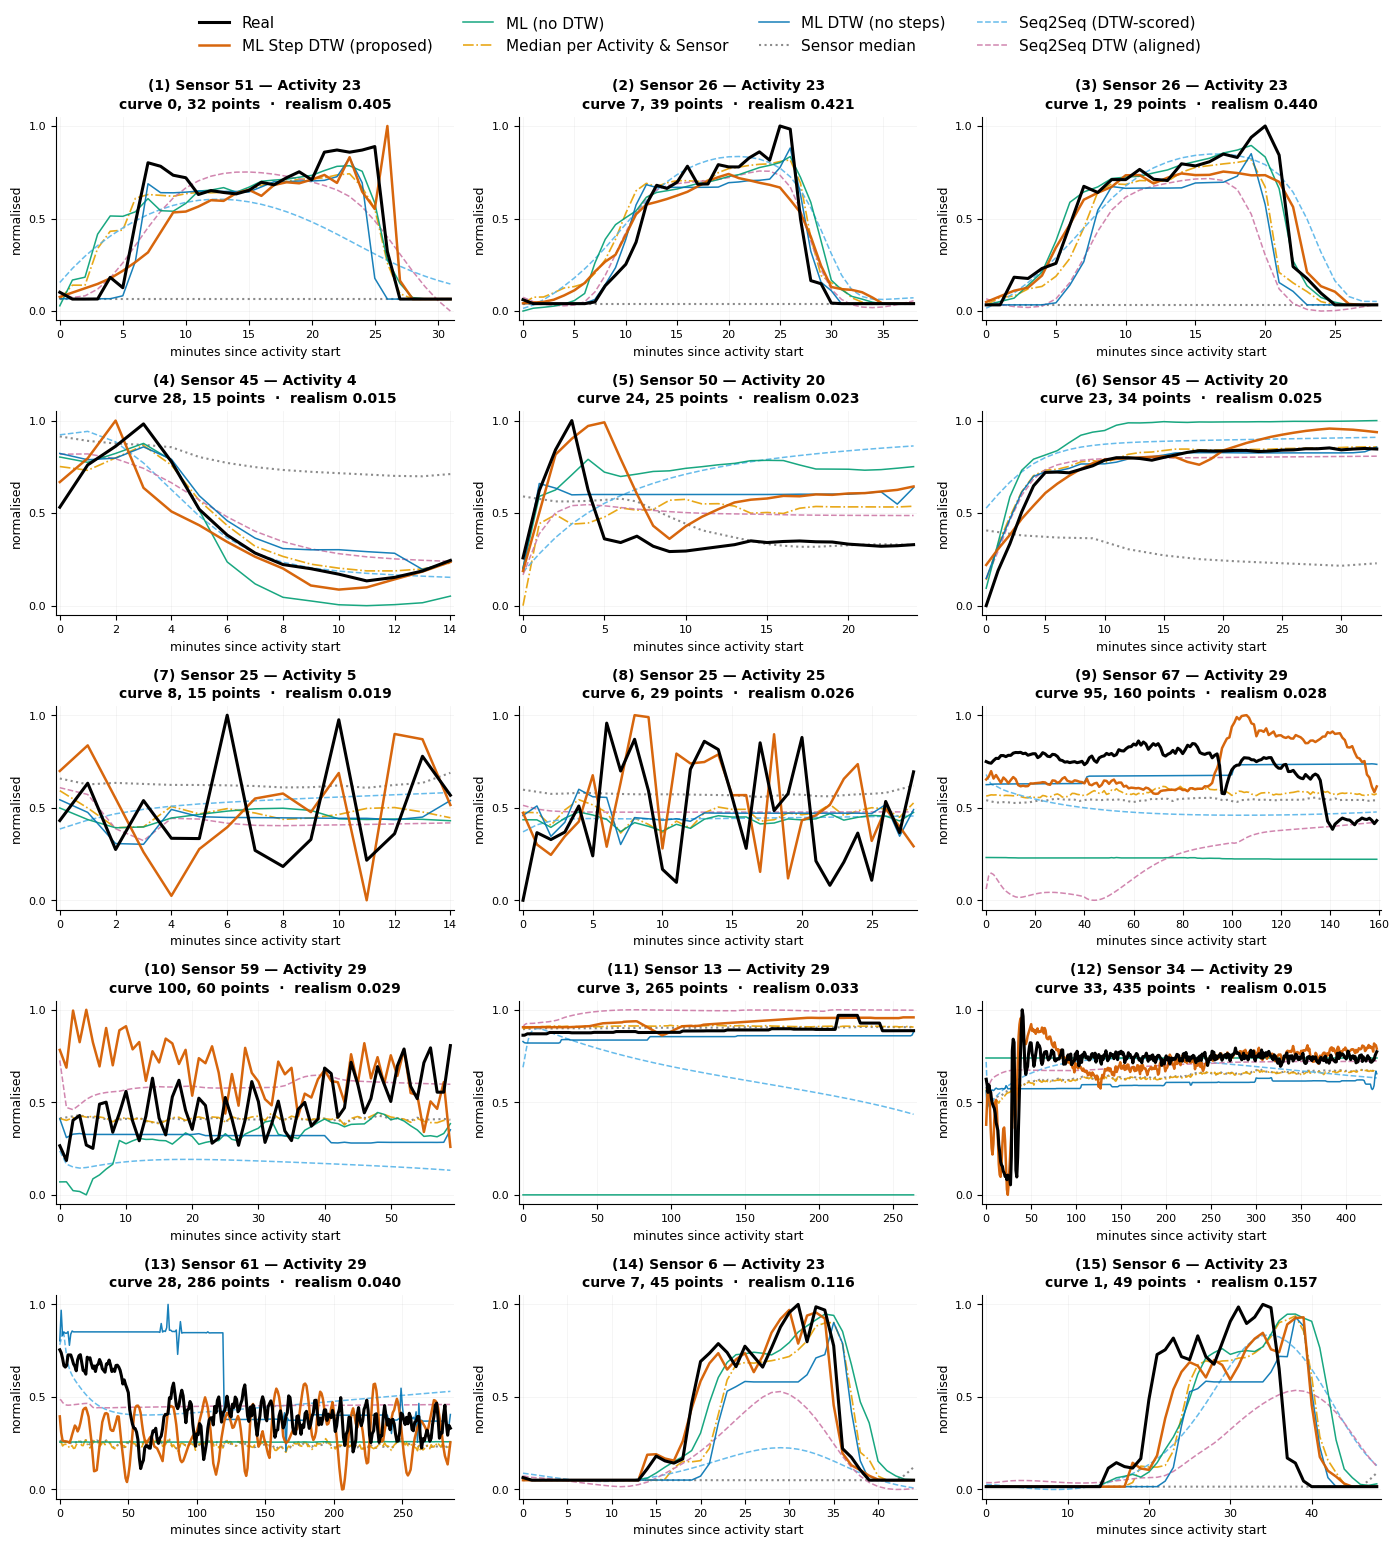

In [9]:

# ── Layout: panels flow through the grid, N_COLS wide ────────────────────────
# selected is already in displayed process order, so panels stay grouped by
# process even without the row labels (removed on purpose — no process names in
# the figure). Panels are numbered (1), (2), ... in reading order, so the text
# can point at one.
# A function that RETURNS the figure: plt.show() draws nothing inside a widget
# callback (the inline backend only flushes on cell execution), so the picker
# and this cell both display() the returned figure instead.
def render_grid():
    _n = len(selected)
    _nrows = int(np.ceil(_n / N_COLS))

    fig, axes = plt.subplots(_nrows, N_COLS, figsize=(4.7 * N_COLS, 3.1 * _nrows))
    axes = np.atleast_2d(axes)

    for _i in range(_nrows * N_COLS):
        _ax = axes[_i // N_COLS, _i % N_COLS]
        if _i < _n:
            draw_panel(_ax, tuple(selected.loc[_i, CURVE_KEY]), selected.loc[_i],
                       num=_i + 1)
        else:
            _ax.axis('off')

    handles = ([Line2D([0], [0], label='Real', **REAL_STYLE)] +
               [Line2D([0], [0], label=m, **SERIES_STYLE[m]) for m in DRAW_METHODS])
    fig.legend(handles=handles, labels=[h.get_label() for h in handles],
               loc='upper center', ncol=min(4, len(handles)), frameon=False,
               fontsize=FS['legend'], bbox_to_anchor=(0.5, 1.0))

    _leg_rows = int(np.ceil(len(handles) / min(4, len(handles))))
    fig.tight_layout(rect=[0, 0, 1, 1 - 0.020 * _leg_rows])

    if SAVE_PDF:
        Path(SAVE_PDF).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(SAVE_PDF, format='pdf', bbox_inches='tight', dpi=300,
                    facecolor='white')
        print('Saved:', SAVE_PDF)
    plt.close(fig)
    return fig

display(render_grid())

---

### Reading the figure

Every panel is one execution of one activity on one sensor, on its own scale —
the point is the *shape*, not a comparison of levels between panels. `realism`
in the corner is the Overall realism error of the best method on that curve, the
number the curve was selected on; the other methods' errors for the same curves
are in the table below.


In [10]:

# ── The same curves, scored for every method ─────────────────────────────────
# The figure shows the best method at its best; this says what the other methods
# did on exactly those curves — the visual gap, as a number.
_sel_keys = set(map(tuple, selected[CURVE_KEY].to_numpy()))
_all = stats[stats[CURVE_KEY].apply(tuple, axis=1).isin(_sel_keys)].copy()
_all['Curve'] = [f'{label_process(p)} · {label_sensor(p, s)} · {label_activity(a)} #{i}'
                 for p, s, a, i in _all[CURVE_KEY].to_numpy()]

_wide = (_all.pivot_table(index='Curve', columns='Method', values='Overall')
             .reindex(columns=[m for m in ranking.index if m in set(_all['Method'])]))
display(_wide.round(3).style
        .background_gradient(cmap='Blues_r', axis=1)
        .format('{:.3f}', na_rep='-')
        .set_caption(f'Overall realism error per curve and method ({SPLIT}); '
                     f'0 = perfect, lower is better'))
print('Median over the drawn curves:')
display(_wide.median().round(3).to_frame('Overall realism'))

Method,ML Step DTW (proposed),ML (no DTW),Median per Activity & Sensor,ML DTW (no steps),Sensor median,Seq2Seq (DTW-scored),Seq2Seq DTW (aligned)
Curve,,,,,,,
Process 1 · Sensor 26 · Activity 23 #1,0.440,0.162,0.583,0.815,3.551,0.289,1.114
Process 1 · Sensor 26 · Activity 23 #7,0.421,0.450,0.503,0.257,3.357,0.666,0.340
Process 1 · Sensor 51 · Activity 23 #0,0.405,0.258,0.373,0.457,3.216,0.967,0.418
Process 2 · Sensor 45 · Activity 20 #23,0.025,0.031,0.069,0.078,0.315,0.203,0.086
Process 2 · Sensor 45 · Activity 4 #28,0.015,0.173,0.152,0.186,0.514,0.155,0.259
Process 2 · Sensor 50 · Activity 20 #24,0.023,0.165,0.165,0.207,0.210,0.125,0.240
Process 3 · Sensor 25 · Activity 25 #6,0.026,0.147,0.133,0.126,0.158,0.155,0.154
Process 3 · Sensor 25 · Activity 5 #8,0.019,0.111,0.103,0.101,0.117,0.107,0.101
Process 4 · Sensor 13 · Activity 29 #3,0.033,1.021,0.292,0.209,0.321,1.526,0.124


Median over the drawn curves:


,Overall realism
Method,
ML Step DTW (proposed),0.029
ML (no DTW),0.205
Median per Activity & Sensor,0.252
ML DTW (no steps),0.257
Sensor median,0.365
Seq2Seq (DTW-scored),0.289
Seq2Seq DTW (aligned),0.259
